In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [35]:
df = pd.read_excel('./data/Online_Retail.xlsx', header=0).iloc[0:, 1:]
print(df.shape)
df.head()

(541909, 7)


,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   StockCode    541909 non-null  object        
 1   Description  540455 non-null  object        
 2   Quantity     541909 non-null  int64         
 3   InvoiceDate  541909 non-null  datetime64[us]
 4   UnitPrice    541909 non-null  float64       
 5   CustomerID   406829 non-null  float64       
 6   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(1)
memory usage: 28.9+ MB


In [37]:
df['Datetime'] = pd.to_datetime(df['InvoiceDate'])
df['Datetime']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: Datetime, Length: 541909, dtype: datetime64[us]

In [38]:
df.isnull().sum()

StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Datetime            0
dtype: int64

In [39]:
df['year'] = df.Datetime.apply(lambda x: x.year)
df['month'] = df.Datetime.apply(lambda x: x.month)
df['day'] = df.Datetime.apply(lambda x: x.day)
df['hour'] = df.Datetime.apply(lambda x: x.hour)
df['minute'] = df.Datetime.apply(lambda x: x.minute)
df.head()

,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Datetime,year,month,day,hour,minute
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01 08:26:00,2010,12,1,8,26
1,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,2010,12,1,8,26
2,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01 08:26:00,2010,12,1,8,26
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,2010,12,1,8,26
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,2010,12,1,8,26


In [40]:
df.shape

(541909, 13)

In [41]:
# CustomerID 없는 행 제거, 취소/반품(Quantity 음수) 거래 제거
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df.shape

(397924, 13)

In [42]:
# Datetime은 InvoiceDate와 중복이라 제거. InvoiceDate는 Recency 계산에 필요하니 남겨둠
drop_cols = ['Datetime']
df.drop(drop_cols, axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   StockCode    397924 non-null  object        
 1   Description  397924 non-null  object        
 2   Quantity     397924 non-null  int64         
 3   InvoiceDate  397924 non-null  datetime64[us]
 4   UnitPrice    397924 non-null  float64       
 5   CustomerID   397924 non-null  float64       
 6   Country      397924 non-null  str           
 7   year         397924 non-null  int64         
 8   month        397924 non-null  int64         
 9   day          397924 non-null  int64         
 10  hour         397924 non-null  int64         
 11  minute       397924 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(6), object(2), str(1)
memory usage: 39.5+ MB


In [43]:
# Recency 기준일: 데이터 내 마지막 거래일 다음 날로 설정
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [44]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

customer_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('StockCode', 'count'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(customer_df.shape)
customer_df.head()

(4339, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,182,4310.00
2,12348.0,75,31,1797.24
3,12349.0,19,73,1757.55
4,12350.0,310,17,334.40


In [45]:
customer_df[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,91.708689,2053.793018
std,100.009747,228.792852,8988.248381
min,1.000000,1.000000,0.000000
25%,18.000000,17.000000,307.245000
50%,51.000000,41.000000,674.450000
75%,142.000000,100.000000,1661.640000
max,374.000000,7847.000000,280206.020000


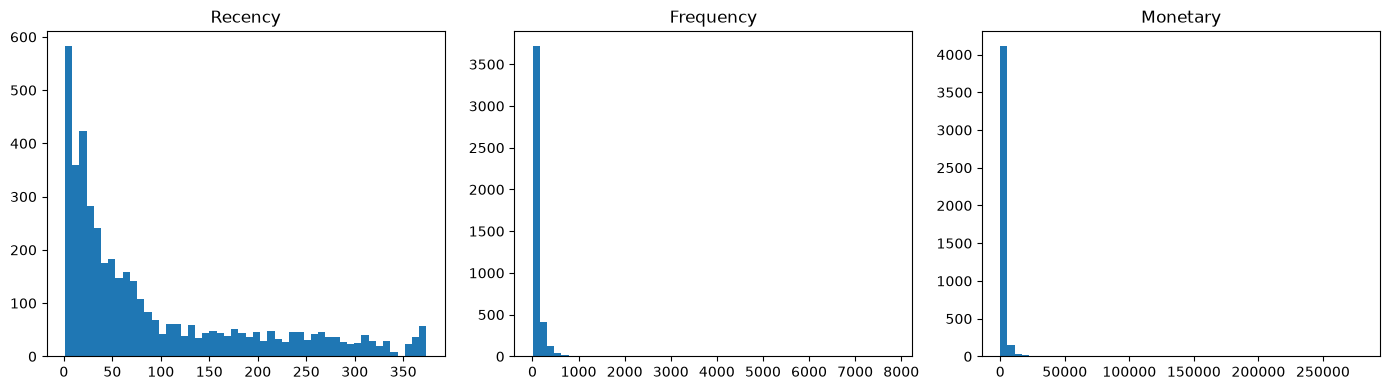

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(customer_df['Recency'], bins=50)
axes[0].set_title('Recency')
axes[1].hist(customer_df['Frequency'], bins=50)
axes[1].set_title('Frequency')
axes[2].hist(customer_df['Monetary'], bins=50)
axes[2].set_title('Monetary')
plt.tight_layout()
plt.show()

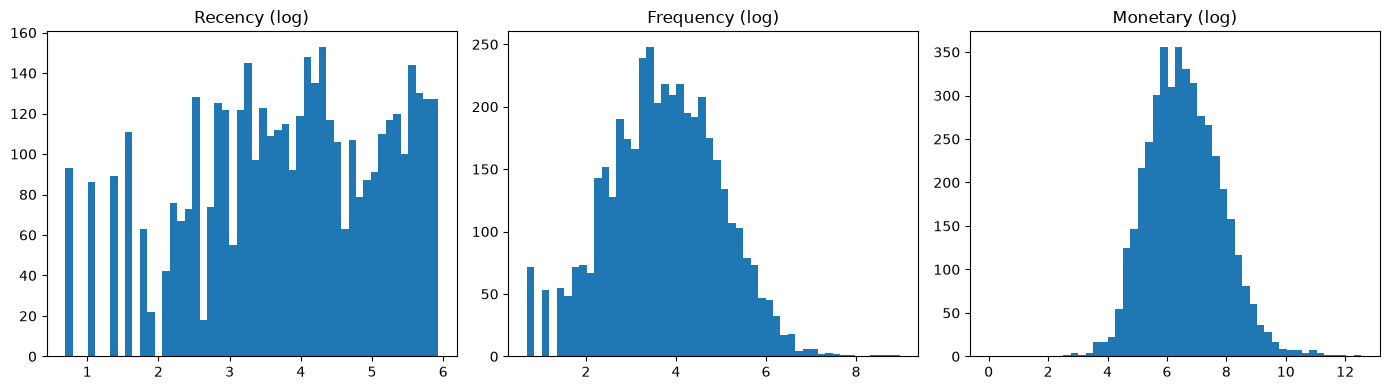

In [47]:
# Frequency, Monetary는 꼬리가 긴 분포라 로그 변환으로 압축
# Recency도 세 feature 스케일을 일관되게 맞추기 위해 동일하게 로그 변환
customer_df['Recency_log'] = np.log1p(customer_df['Recency'])
customer_df['Frequency_log'] = np.log1p(customer_df['Frequency'])
customer_df['Monetary_log'] = np.log1p(customer_df['Monetary'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(customer_df['Recency_log'], bins=50)
axes[0].set_title('Recency (log)')
axes[1].hist(customer_df['Frequency_log'], bins=50)
axes[1].set_title('Frequency (log)')
axes[2].hist(customer_df['Monetary_log'], bins=50)
axes[2].set_title('Monetary (log)')
plt.tight_layout()
plt.show()

In [48]:
from sklearn.preprocessing import StandardScaler

X = customer_df[['Recency_log', 'Frequency_log', 'Monetary_log']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.46223615, -2.43282745,  3.69616759],
       [-2.03861142,  1.17736943,  1.40875812],
       [ 0.37331015, -0.21652101,  0.71551656],
       [-0.62291426,  0.45360881,  0.69782099],
       [ 1.42479959, -0.67644615, -0.61587654]])

In [49]:
# 03.ipynb와 동일한 흐름: 일단 4개로 시작
kmeans = KMeans(n_clusters=4,
                init='k-means++',
                max_iter=300,
                random_state=42)

cluster_labels = kmeans.fit_predict(X_scaled)
customer_df['cluster'] = cluster_labels

customer_df['cluster'].value_counts()

cluster
2    1378
3    1222
0     872
1     867
Name: count, dtype: int64

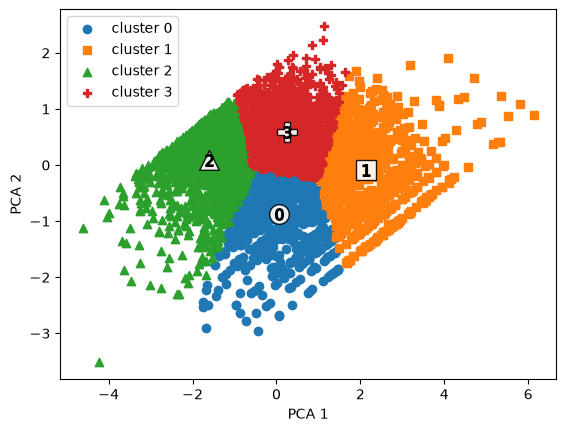

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

centers = kmeans.cluster_centers_
centers_pca = pca.transform(centers)

customer_df['pca_1'] = pca_result[:, 0]
customer_df['pca_2'] = pca_result[:, 1]

markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

for label in sorted(customer_df['cluster'].unique()):
    cluster_data = customer_df[customer_df['cluster'] == label]
    center = centers_pca[label]

    plt.scatter(x=cluster_data['pca_1'],
                y=cluster_data['pca_2'],
                marker=markers[label],
                label=f'cluster {label}')

    plt.scatter(x=center[0],
                y=center[1],
                s=200,
                color='white',
                alpha=0.9,
                edgecolor='k',
                marker=markers[label])
    plt.scatter(x=center[0],
                y=center[1],
                s=70,
                color='k',
                edgecolor='k',
                marker='$%d$' % label)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

In [51]:
from sklearn.metrics import silhouette_score, silhouette_samples

score = silhouette_score(X_scaled, customer_df['cluster'])
print(score)

0.3082848091892372


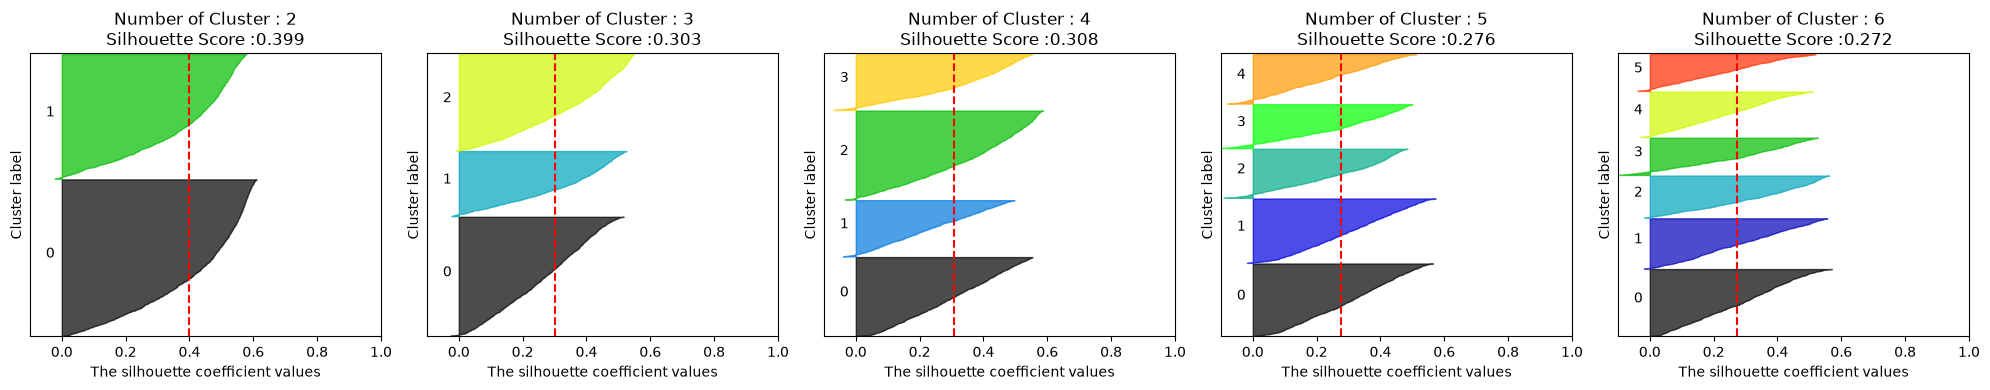

In [52]:
def visualize_silhouette(cluster_lists, X_features):

    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm

    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    for ind, n_cluster in enumerate(cluster_lists):

        clusterer = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : ' + str(n_cluster) + '\n' \
                          'Silhouette Score :' + str(round(sil_avg, 3)))
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels == i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                                    facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

    plt.tight_layout()
    plt.show()

visualize_silhouette([2, 3, 4, 5, 6], X_scaled)

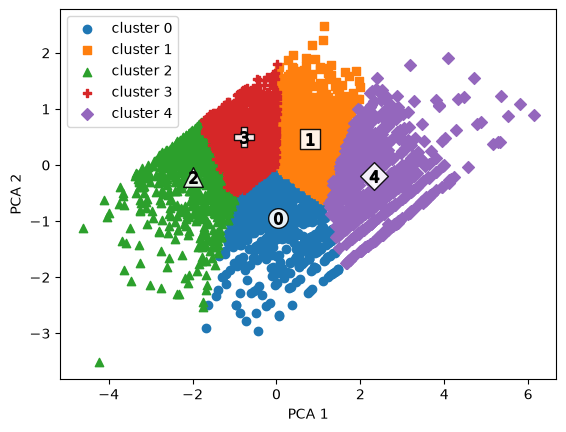

silhouette score: 0.2763452142678691


,Recency,Frequency,Monetary
cluster,,,
0,18.516927,35.934896,590.183517
1,57.930279,111.544821,1976.303537
2,181.095675,8.187418,197.660341
3,164.552585,33.239750,642.943754
4,9.164223,314.945748,8213.695718


In [54]:
# 위 결과 보고 가장 적절한 k로 최종 결정 (예시로 3을 넣어뒀으니 결과에 맞게 수정)
final_k = 5

kmeans = KMeans(n_clusters=final_k,
                init='k-means++',
                max_iter=300,
                random_state=42)

cluster_labels = kmeans.fit_predict(X_scaled)
customer_df['cluster'] = cluster_labels

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
customer_df['pca_1'] = pca_result[:, 0]
customer_df['pca_2'] = pca_result[:, 1]

centers_pca = pca.transform(kmeans.cluster_centers_)

markers = ['o', 's', '^', 'P', 'D', 'H', 'x']
for label in sorted(customer_df['cluster'].unique()):
    cluster_data = customer_df[customer_df['cluster'] == label]
    center = centers_pca[label]

    plt.scatter(x=cluster_data['pca_1'], y=cluster_data['pca_2'],
                marker=markers[label], label=f'cluster {label}')
    plt.scatter(x=center[0], y=center[1], s=200, color='white',
                alpha=0.9, edgecolor='k', marker=markers[label])
    plt.scatter(x=center[0], y=center[1], s=70, color='k',
                edgecolor='k', marker='$%d$' % label)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

print('silhouette score:', silhouette_score(X_scaled, customer_df['cluster']))
customer_df.groupby('cluster')[['Recency', 'Frequency', 'Monetary']].mean()